# Exploratory Data Analysis

Comprehensive EDA and visualization of the cleaned dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')

Loaded dataset: 11,232 rows × 28 columns


### 1) Sales trend analysis

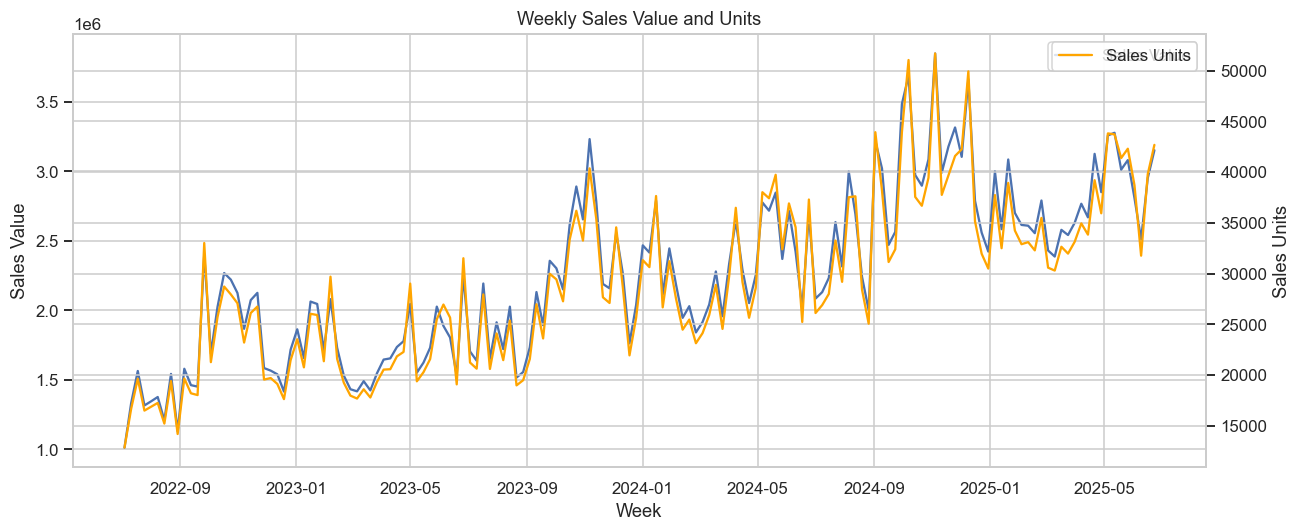

Insight: Peak weekly Sales_Value occurred on 2024-11-04 (highest single-week revenue).
Consider investigating promotions or large channel spend around this week.


### 2) Marketing channel trend analysis

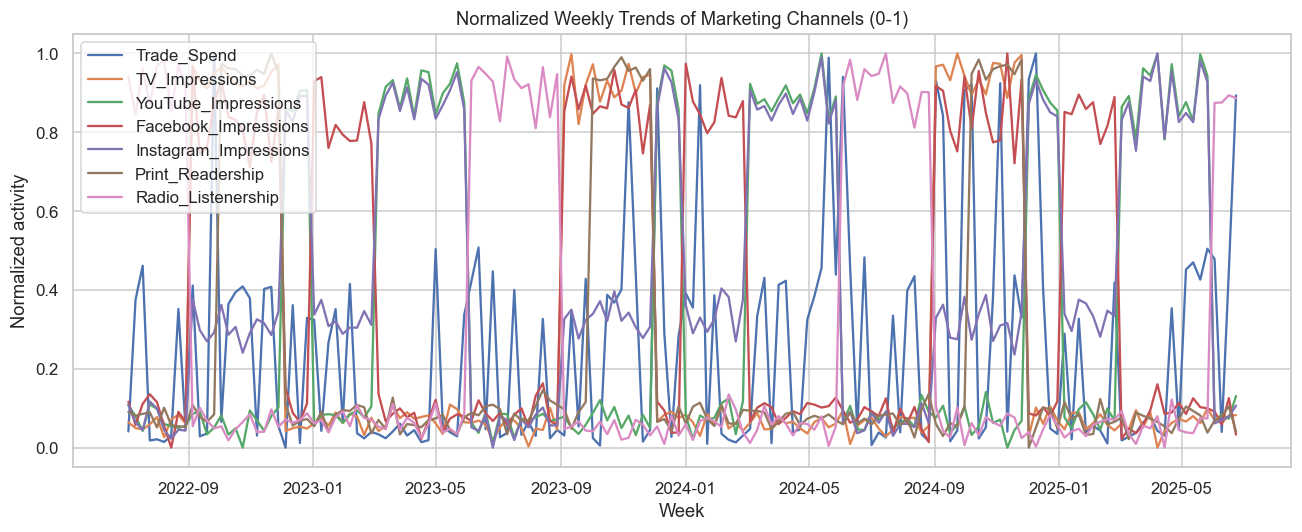

Insight: 'Trade_Spend' shows the largest relative increase over the period.


### 3) Correlation heatmap

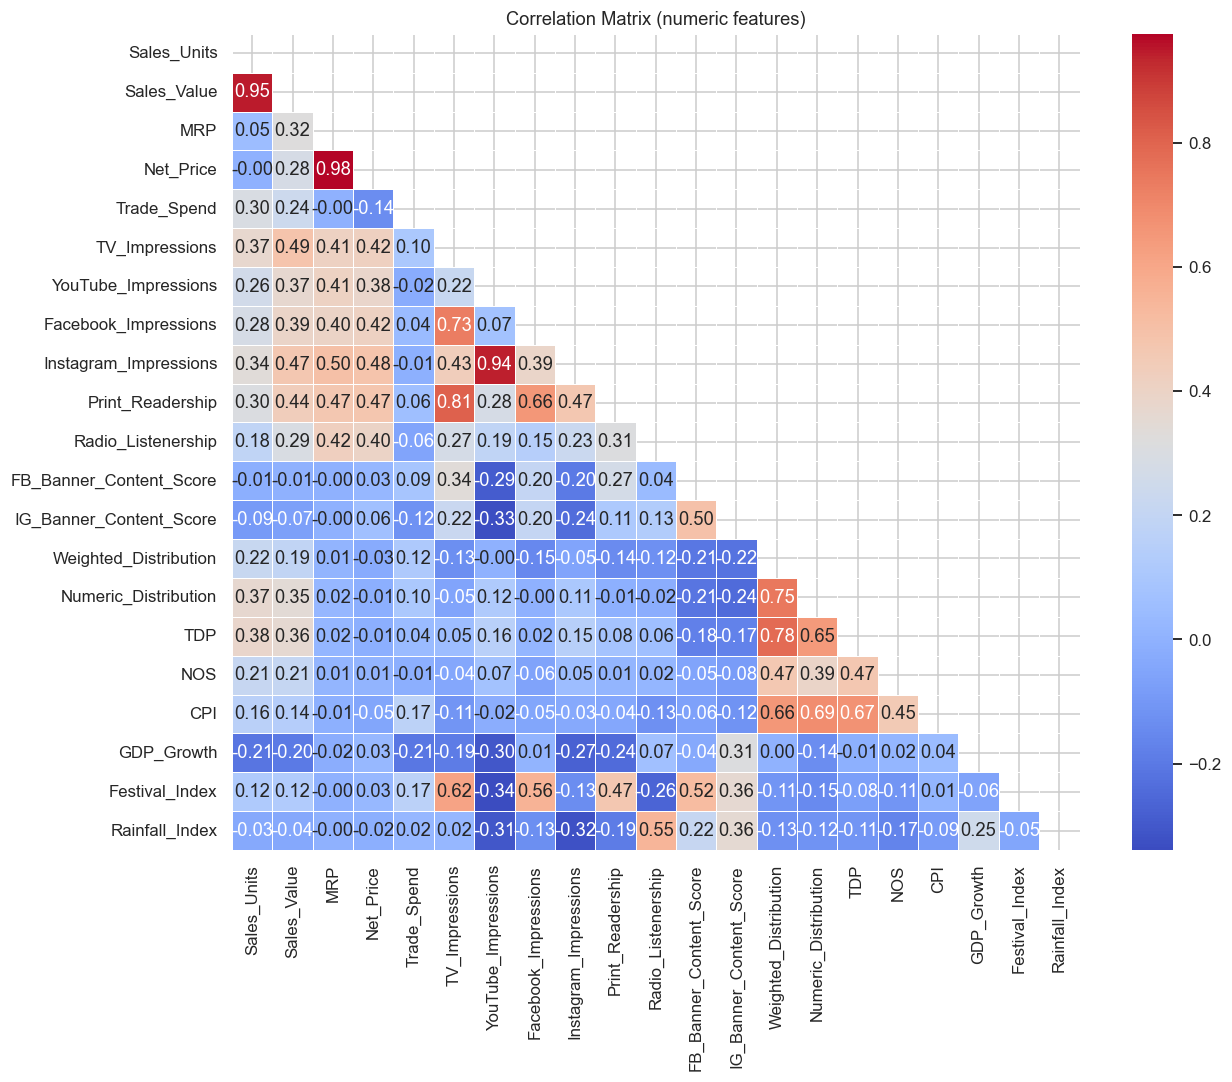

Insight: Top correlations with Sales_Value:
Sales_Units              0.945649
TV_Impressions           0.487114
Instagram_Impressions    0.469633
Print_Readership         0.435410
Facebook_Impressions     0.394919


### 4) Geo-wise sales analysis

C:\Users\Archita Singh\AppData\Local\Temp\ipykernel_21016\2523794396.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_geo.values, y=top_geo.index, palette='viridis')


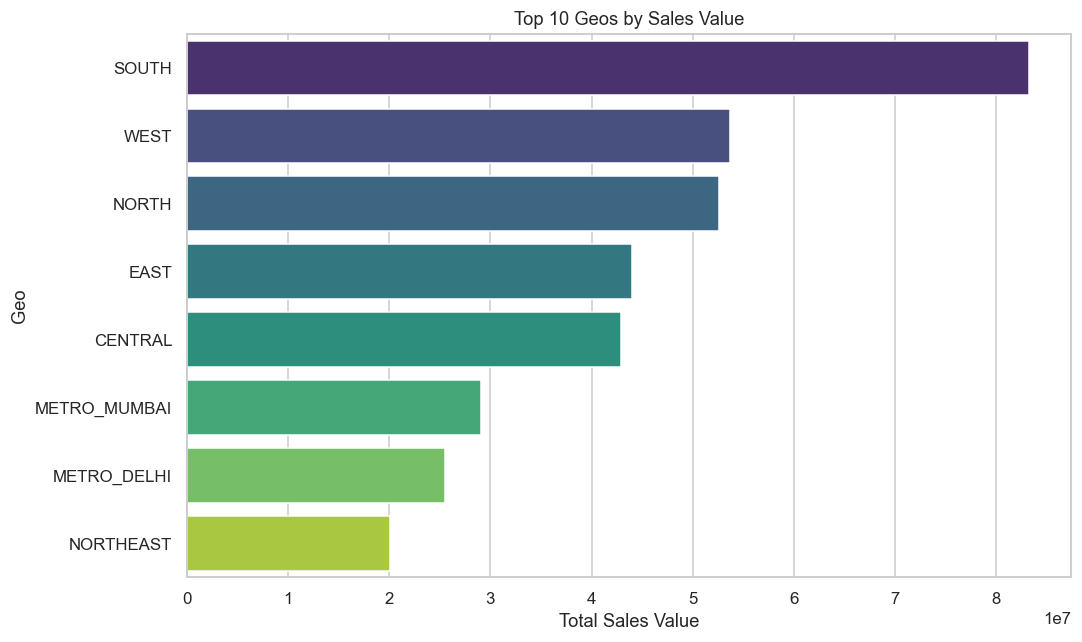

Insight: Top 10 geos account for 100.0% of total Sales_Value.


### 5) Brand-wise sales analysis

C:\Users\Archita Singh\AppData\Local\Temp\ipykernel_21016\2523794396.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='magma')


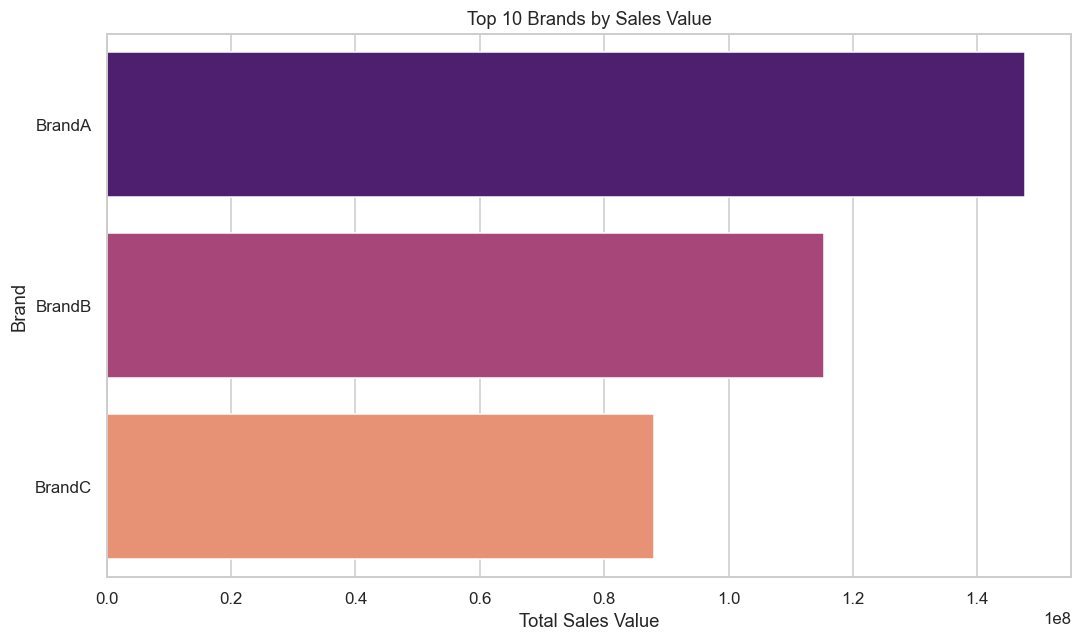

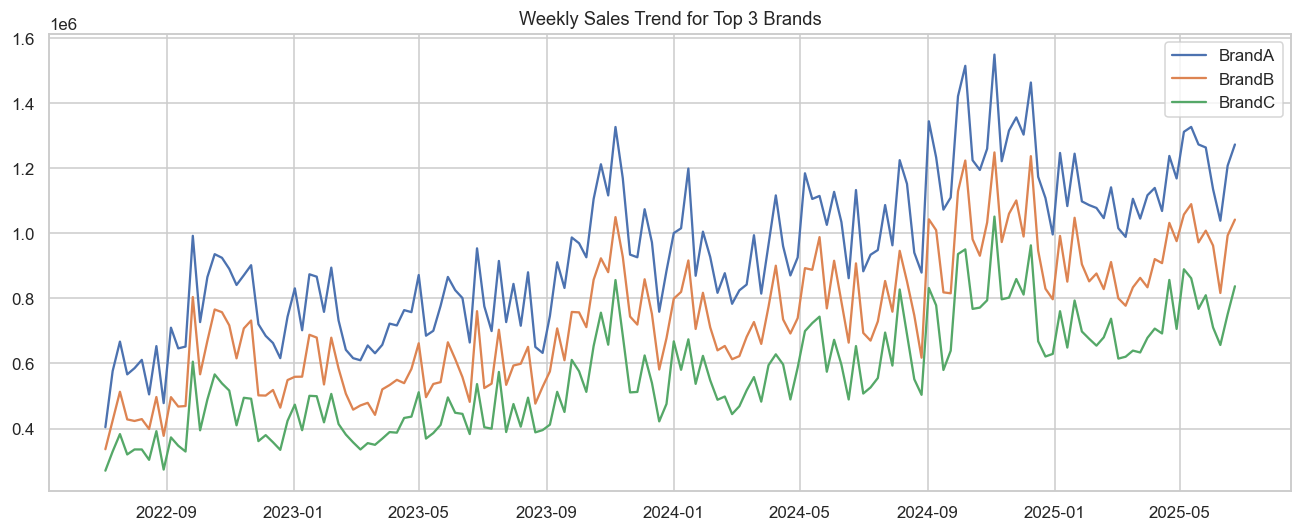

Insight: BrandA, BrandB, BrandC are the top 3 revenue-driving brands; analyze promotions and channel mixes supporting them.


### 6) Distribution plots

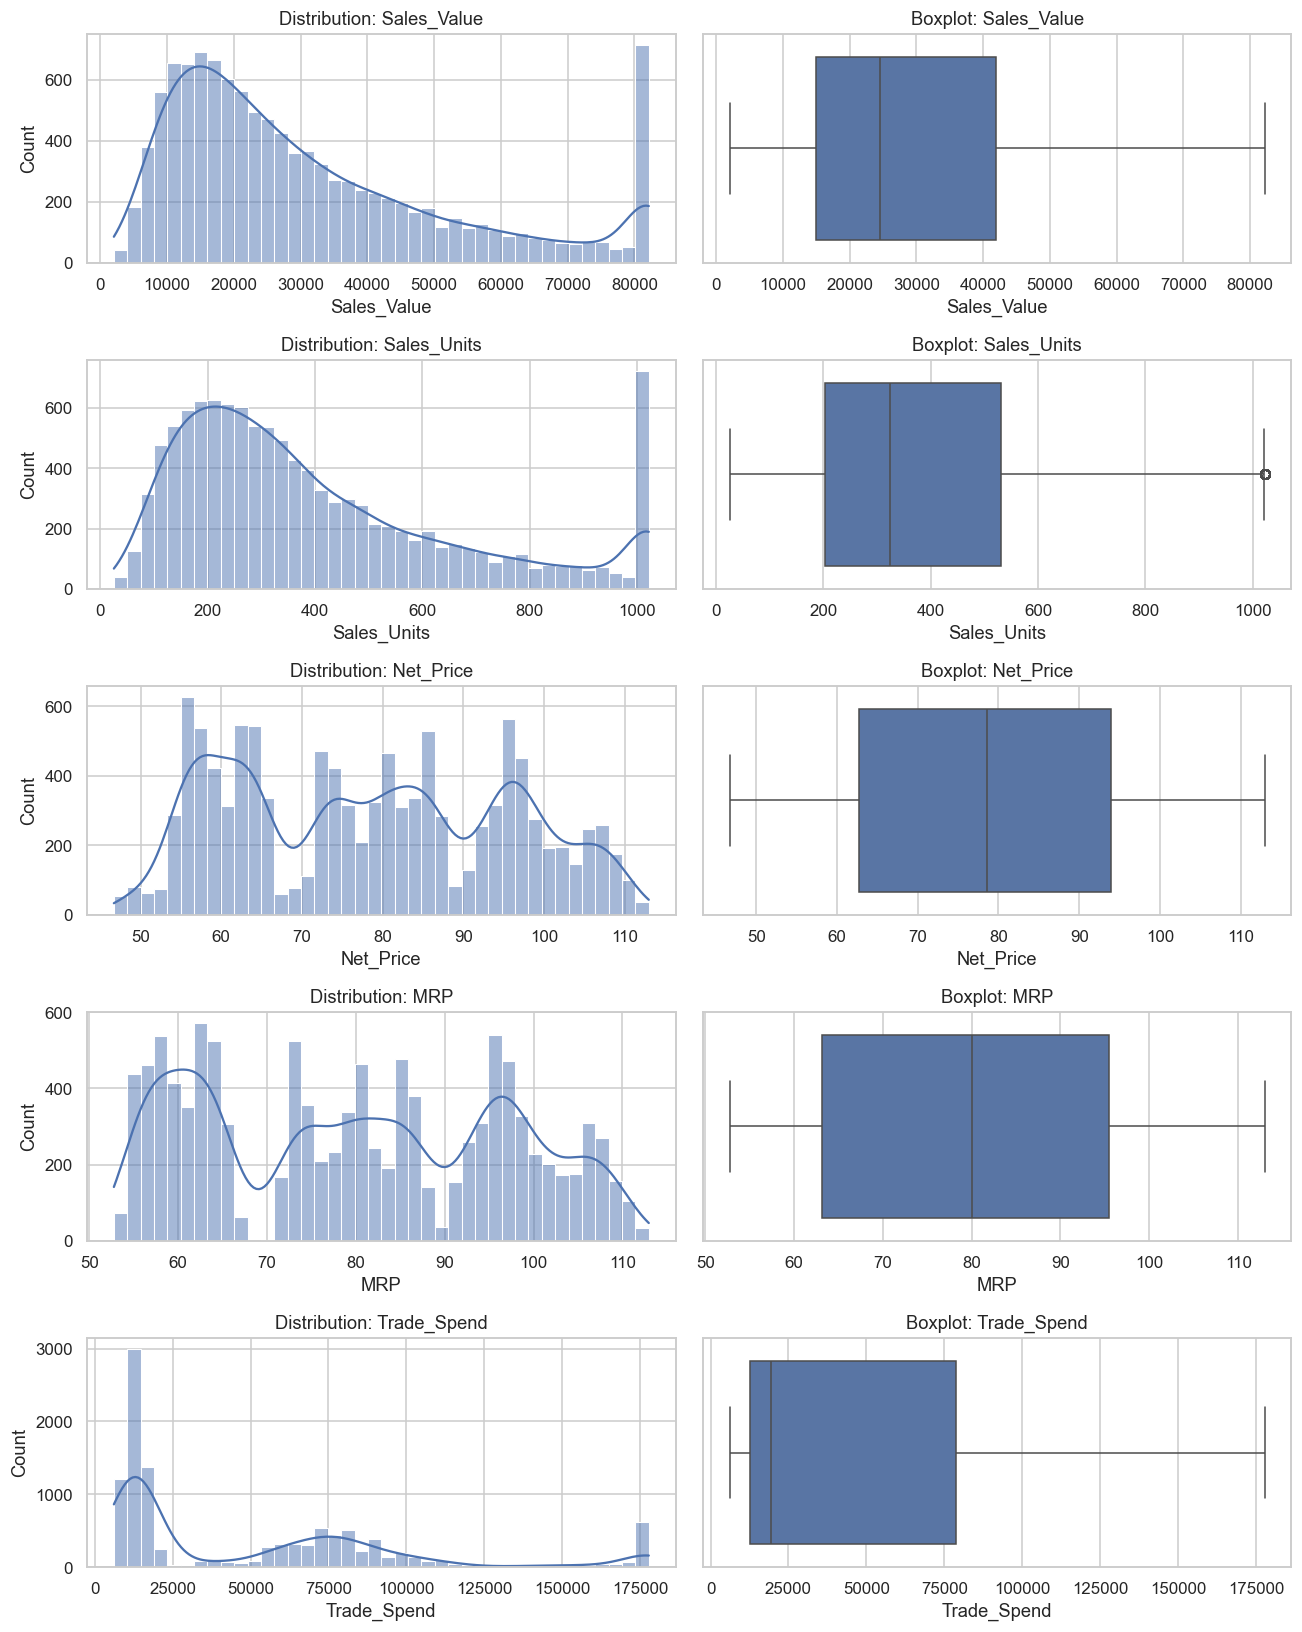

Insight: Check skew and outliers for the above key business metrics; consider log-transform for heavy right-skewed variables in modelling.

EDA complete: key charts and inline insights printed above.


In [3]:
# EDA: Sales & Marketing - consolidated analyses and insights
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Load cleaned data if available, otherwise fall back to raw
clean_path = Path('../data/processed/cleaned_data.csv')
raw_path = Path('../data/raw/synthetic_mmm_weekly_india.csv')
if clean_path.exists():
    df = pd.read_csv(clean_path, parse_dates=['Week'])
else:
    df = pd.read_csv(raw_path, parse_dates=['Week'])

# Basic prep
df['Week'] = pd.to_datetime(df['Week'], errors='coerce')
df = df.sort_values('Week').reset_index(drop=True)
print(f"Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Helper: safe column getter
def cols_exist(cols):
    return [c for c in cols if c in df.columns]

# 1) Sales trend analysis
display(Markdown('### 1) Sales trend analysis'))
weekly_sales = df.groupby('Week').agg({'Sales_Value': 'sum', 'Sales_Units': 'sum'}).reset_index()
plt.figure(figsize=(12,5))
ax = sns.lineplot(data=weekly_sales, x='Week', y='Sales_Value', label='Sales Value')
ax2 = ax.twinx()
sns.lineplot(data=weekly_sales, x='Week', y='Sales_Units', color='orange', label='Sales Units', ax=ax2)
ax.set_title('Weekly Sales Value and Units')
ax.set_ylabel('Sales Value')
ax2.set_ylabel('Sales Units')
ax.figure.tight_layout()
plt.show()

# Insight
peak_week = weekly_sales.loc[weekly_sales['Sales_Value'].idxmax(), 'Week'].date()
print(f"Insight: Peak weekly Sales_Value occurred on {peak_week} (highest single-week revenue).")
print('Consider investigating promotions or large channel spend around this week.')

# 2) Marketing channel trend analysis
display(Markdown('### 2) Marketing channel trend analysis'))
channel_candidates = ['Trade_Spend','TV_Impressions','YouTube_Impressions','Facebook_Impressions','Instagram_Impressions','Print_Readership','Radio_Listenership']
channels = cols_exist(channel_candidates)
if channels:
    weekly_channels = df.groupby('Week')[channels].sum().reset_index()
    # normalize for comparability
    ch_norm = weekly_channels.set_index('Week')
    ch_norm = (ch_norm - ch_norm.min()) / (ch_norm.max() - ch_norm.min())
    plt.figure(figsize=(12,5))
    for c in ch_norm.columns:
        plt.plot(ch_norm.index, ch_norm[c], label=c)
    plt.legend(loc='upper left')
    plt.title('Normalized Weekly Trends of Marketing Channels (0-1)')
    plt.xlabel('Week')
    plt.ylabel('Normalized activity')
    plt.tight_layout()
    plt.show()

    # Insight: channel with strongest relative increase
    change = (ch_norm.iloc[-1] - ch_norm.iloc[0]).sort_values(ascending=False)
    top = change.index[0]
    print(f"Insight: '{top}' shows the largest relative increase over the period.")
else:
    print('No common marketing channel columns found in dataset to plot trends.')

# 3) Correlation heatmap
display(Markdown('### 3) Correlation heatmap'))
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# drop id-like or low-variance columns if present
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    plt.figure(figsize=(12,10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
    plt.title('Correlation Matrix (numeric features)')
    plt.tight_layout()
    plt.show()

    # Insight: top correlations with Sales_Value
    if 'Sales_Value' in corr.columns:
        top_corr = corr['Sales_Value'].drop('Sales_Value').abs().sort_values(ascending=False)
        print('Insight: Top correlations with Sales_Value:')
        print(top_corr.head(5).to_string())
else:
    print('Not enough numeric columns for correlation heatmap.')

# 4) Geo-wise sales analysis
display(Markdown('### 4) Geo-wise sales analysis'))
if 'Geo' in df.columns and 'Sales_Value' in df.columns:
    geo_sales = df.groupby('Geo')['Sales_Value'].sum().sort_values(ascending=False)
    top_geo = geo_sales.head(10)
    plt.figure(figsize=(10,6))
    sns.barplot(x=top_geo.values, y=top_geo.index, palette='viridis')
    plt.xlabel('Total Sales Value')
    plt.title('Top 10 Geos by Sales Value')
    plt.tight_layout()
    plt.show()

    total = geo_sales.sum()
    top_share = top_geo.sum() / total
    print(f"Insight: Top 10 geos account for {top_share:.1%} of total Sales_Value.")
else:
    print('Geo or Sales_Value columns missing; cannot compute geo-wise analysis.')

# 5) Brand-wise sales analysis
display(Markdown('### 5) Brand-wise sales analysis'))
if 'Brand' in df.columns and 'Sales_Value' in df.columns:
    brand_sales = df.groupby('Brand')['Sales_Value'].sum().sort_values(ascending=False)
    top_brands = brand_sales.head(10)
    plt.figure(figsize=(10,6))
    sns.barplot(x=top_brands.values, y=top_brands.index, palette='magma')
    plt.xlabel('Total Sales Value')
    plt.title('Top 10 Brands by Sales Value')
    plt.tight_layout()
    plt.show()

    # Trend of top 3 brands
    top3 = brand_sales.head(3).index.tolist()
    trend = df[df['Brand'].isin(top3)].groupby(['Week','Brand'])['Sales_Value'].sum().reset_index()
    trend_pivot = trend.pivot(index='Week', columns='Brand', values='Sales_Value').fillna(0)
    plt.figure(figsize=(12,5))
    for b in trend_pivot.columns:
        plt.plot(trend_pivot.index, trend_pivot[b], label=b)
    plt.legend()
    plt.title('Weekly Sales Trend for Top 3 Brands')
    plt.tight_layout()
    plt.show()

    print(f"Insight: {', '.join(top3)} are the top 3 revenue-driving brands; analyze promotions and channel mixes supporting them.")
else:
    print('Brand or Sales_Value columns missing; cannot compute brand-wise analysis.')

# 6) Distribution plots
display(Markdown('### 6) Distribution plots'))
dist_cols = cols_exist(['Sales_Value','Sales_Units','Net_Price','MRP','Trade_Spend'])
if dist_cols:
    n = len(dist_cols)
    plt.figure(figsize=(12,3*n))
    for i,c in enumerate(dist_cols, start=1):
        plt.subplot(n,2,2*i-1)
        sns.histplot(df[c].dropna(), kde=True, bins=40)
        plt.title(f'Distribution: {c}')
        plt.subplot(n,2,2*i)
        sns.boxplot(x=df[c].dropna())
        plt.title(f'Boxplot: {c}')
    plt.tight_layout()
    plt.show()

    print('Insight: Check skew and outliers for the above key business metrics; consider log-transform for heavy right-skewed variables in modelling.')
else:
    print('No typical numeric distribution columns found.')

print('\nEDA complete: key charts and inline insights printed above.')
